# 物体检测算法：R-CNN，SSD，YOLO

目标检测算法主要分为两个类型

（1）two-stage方法，如R-CNN系算法（region-based CNN），其主要思路是先通过启发式方法（selective search）或者CNN网络（RPN)产生一系列稀疏的候选框，然后对这些候选框进行分类与回归，two-stage方法的优势是准确度高

（2）one-stage方法，如Yolo和SSD，其主要思路是均匀地在图片的不同位置进行密集抽样，抽样时可以采用不同尺度和长宽比，然后利用CNN提取特征后直接进行分类与回归，整个过程只需要一步，所以其优势是速度快，但是均匀的密集采样的一个重要缺点是训练比较困难，这主要是因为正样本与负样本（背景）极其不均衡，导致模型准确度稍低

## 区域卷积神经网络 R-CNN

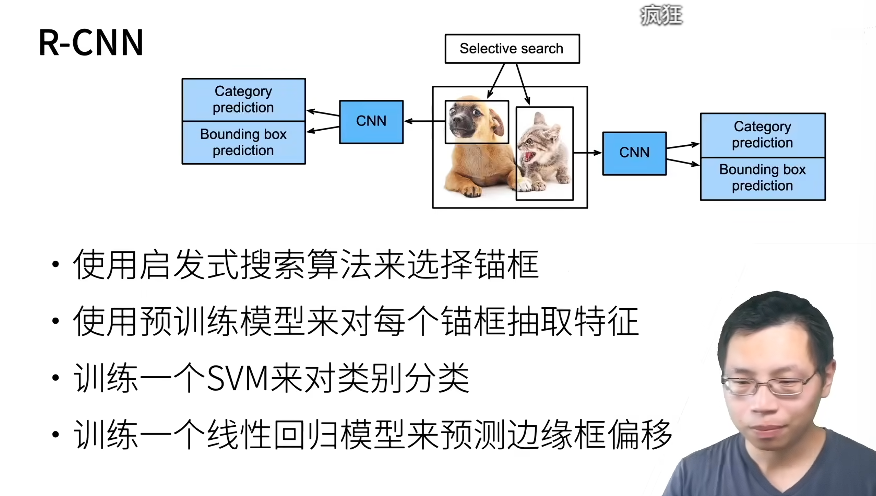

启发式算法选择锚框后，标注其类别和边界框，用CNN对每个锚框抽取特征，再用 SVM 分类

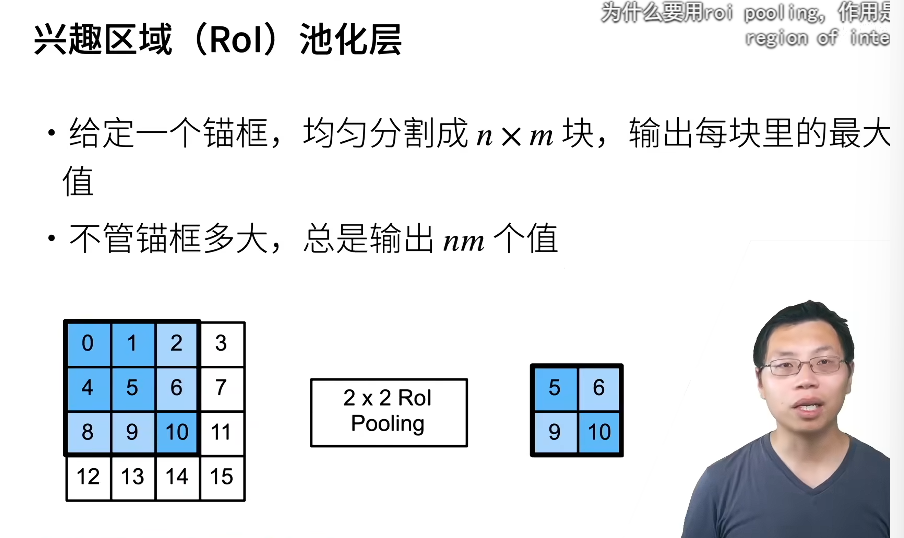

每次选择的锚框的大小是不同的，怎样使这些大小不一的锚框变成一个batch？

Rol 的作用是将不同形状的锚框变为相同形状，方便变为一个批量进行训练

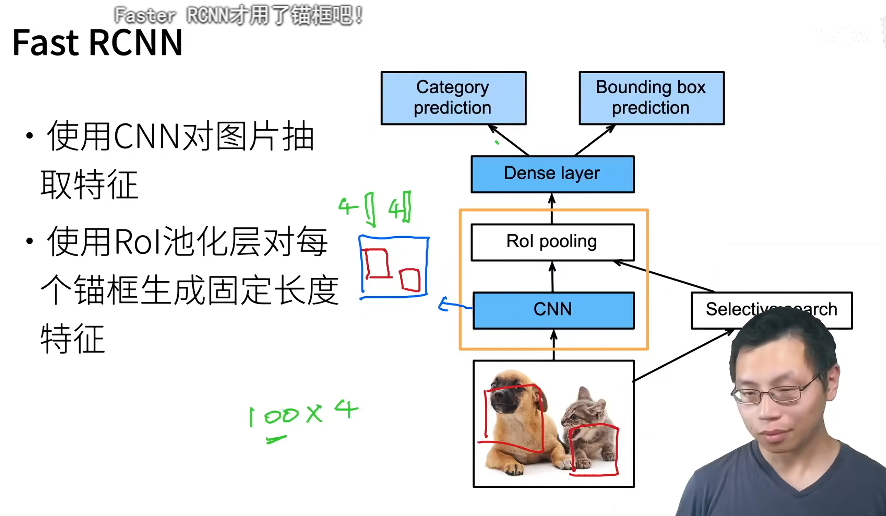

对整个图片特征提取 CNN，再做锚框选择，再用 ROI，再用全连接层分类

Fast R-CNN 相对于 R-CNN 更快的原因是：

Fast R-CNN 中的 CNN 不再对每个锚框抽取特征，而是对整个图片进行特征的提取，然后再在整张图片的feature中找出原图中锚框对应的特征，最后一起做预测

这样做的好处是：不同的锚框之间可能会有重叠的部分，如果对每个锚框都进行特征提取的话，可能会对重叠的区域进行多次重复的特征提取操作

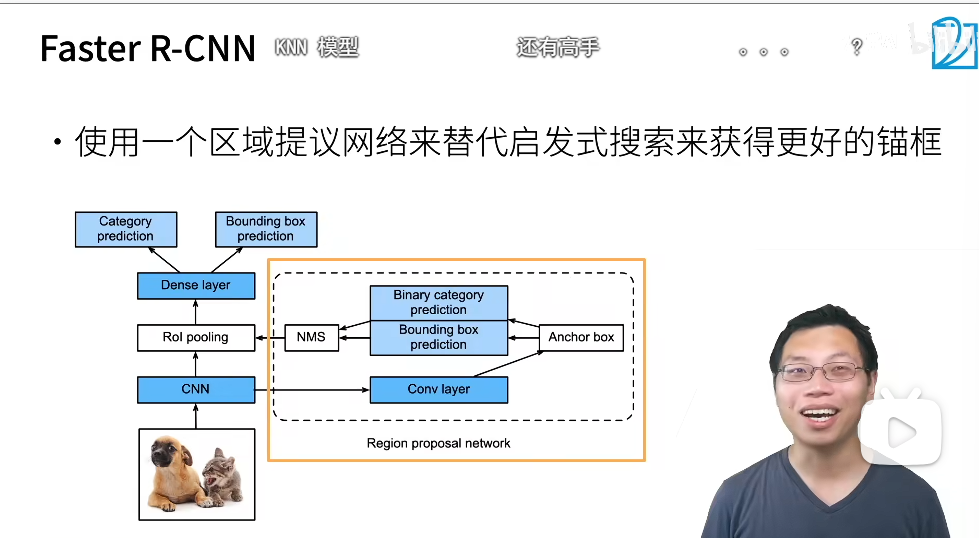

RPN 先生成预候选框，然后在特征层进行回归和分类预测，两次预测

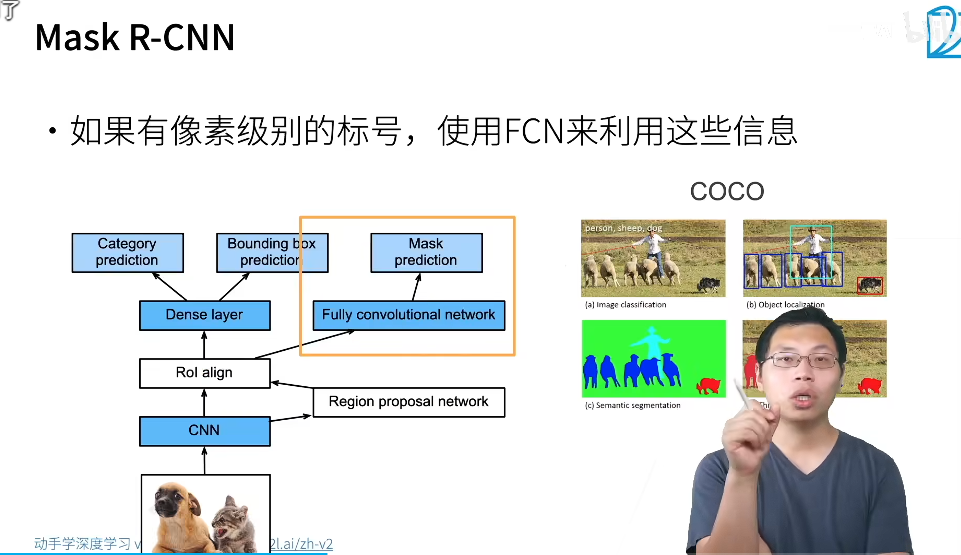

假设有每个像素的标号的话，就可以对每个**像素**做预测（FCN）。

采用多任务训练，增加预测像素的任务，相当于loss多了一项

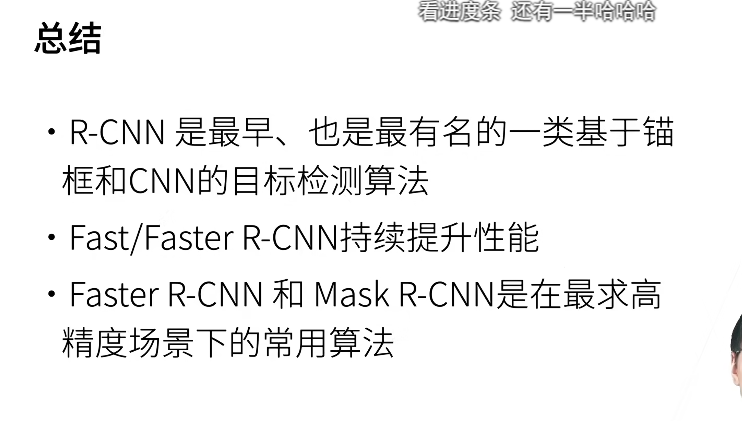

## 单发多框监测（   SSD）

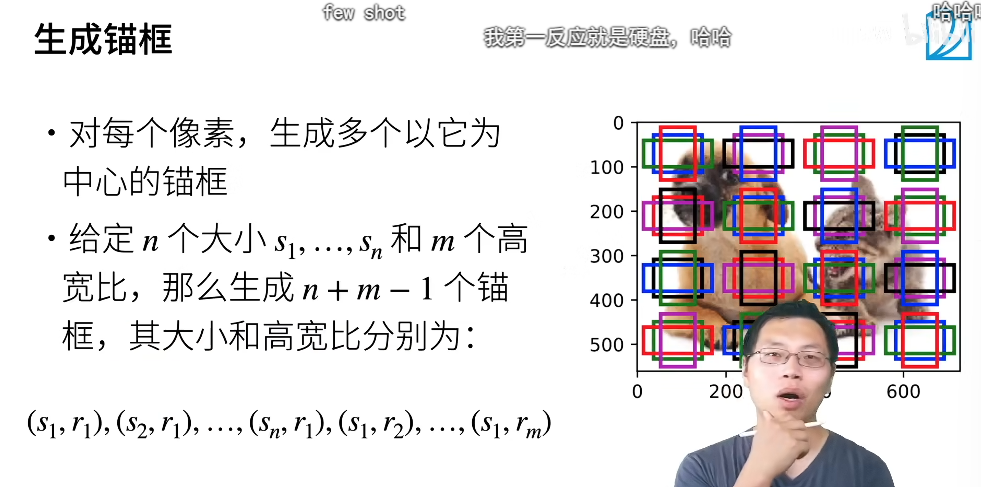

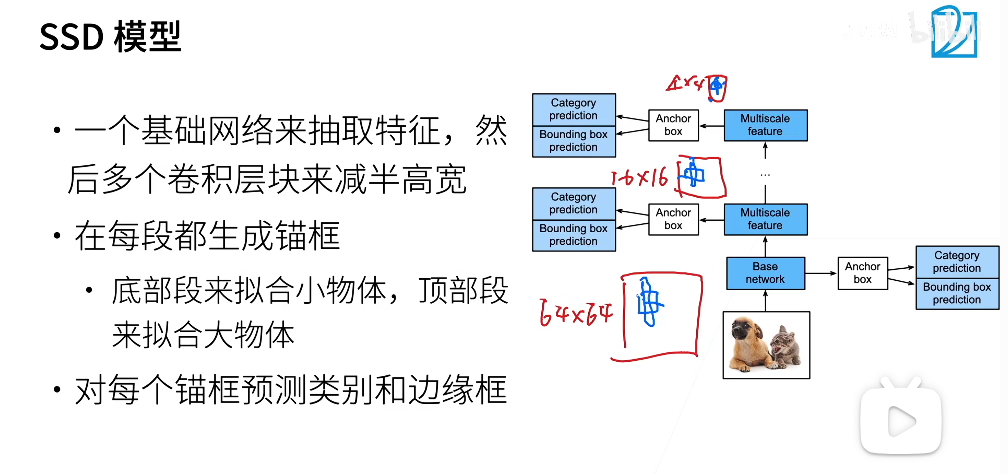

多尺度特征图检测，R-CNN 只在最后一层特征图上检测，而 SSD 抽取了不同层级的特征图。

浅层（大尺寸特征图）：感受野小，负责检测小物体（比如照片里远处的人脸）。

深层（小尺寸特征图）：感受野大，负责检测大物体（比如近处的汽车）。


SSD 相对 R-CNN 比较简单，运行速度较快，但精度较低

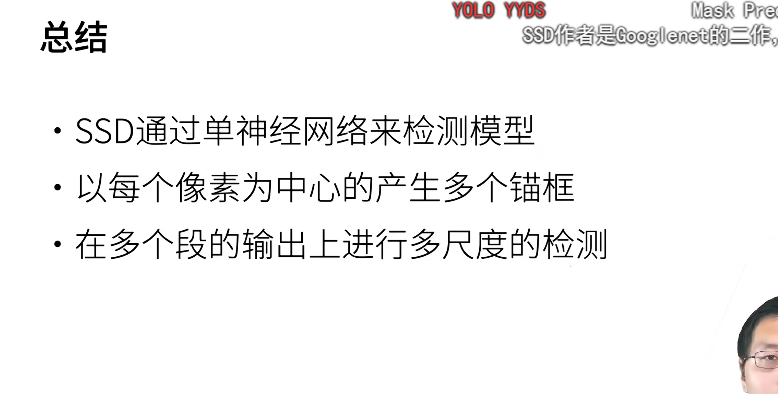

## YOLO （You Only Look Once）

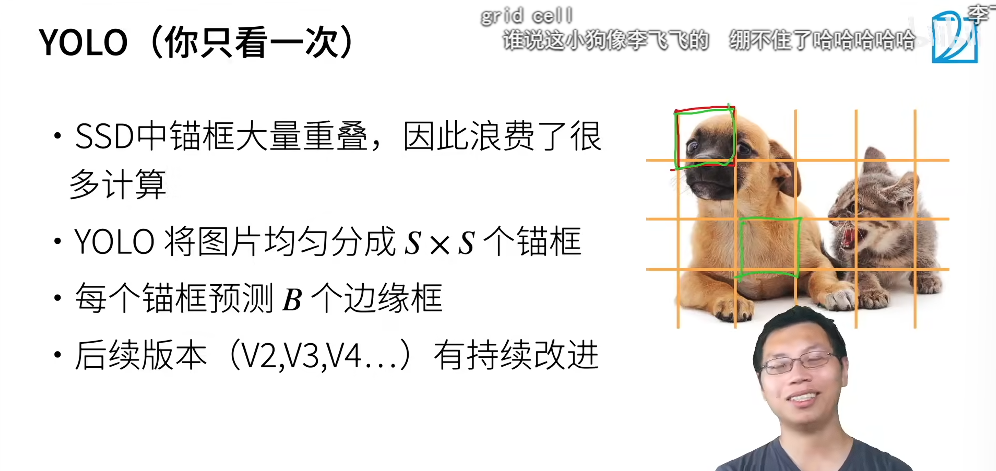

锚框均匀分布不会重叠，每个锚框预测多个边缘框

YOLO 精度高于 SSD，略低于R-CNN，但速度高于R-CNN

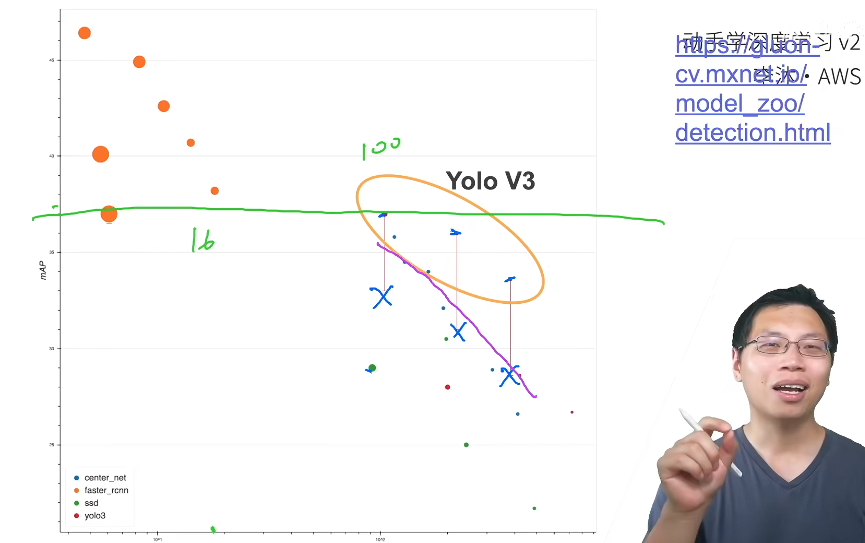